In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN & THÔNG SỐ CƠ BẢN
# ==========================================
# Cập nhật đường dẫn đến các thư mục dữ liệu đã chia của bạn
TRAIN_DIR = "Data\\processed\\classification\\train"
VAL_DIR = "Data\\processed\\classification\\valid"
TEST_DIR = "Data\\processed\\classification\\test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
NUM_CLASSES = 6
EPOCHS = 50

# ==========================================
# 2. NẠP VÀ TIỀN XỬ LÝ DỮ LIỆU TỰ ĐỘNG
# ==========================================
print("--- Loading Datasets ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int', color_mode='grayscale', shuffle=True
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int', color_mode='grayscale', shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int', color_mode='grayscale', shuffle=False
)

# Chuẩn hóa giá trị pixel ảnh từ [0, 255] về [0, 1] để mạng nơ-ron xử lý ổn định
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)


# Bắt buộc: class_names phải khớp thứ tự label của image_dataset_from_directory
class_names = sorted(
    [p.name for p in Path(TRAIN_DIR).iterdir() if p.is_dir()]
)

print(f"Classes detected: {class_names}")

if len(class_names) != NUM_CLASSES:
    raise ValueError(
        f"Expected {NUM_CLASSES} classes, but found {len(class_names)}: {class_names}"
    )

# ==========================================
# 3. ĐỊNH NGHĨA KIẾN TRÚC CUSTOM SIMPLE CNN
# ==========================================

# Data augmentation tối ưu cho phân loại lỗi PCB (Góc chụp thẳng cố định)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
], name="data_augmentation")

def conv_bn_relu(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                      kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    return layers.ReLU()(x)

# def build_simple_cnn(input_shape=(224, 224, 1), num_classes=6):
#     model = models.Sequential([
#         layers.Input(shape=input_shape),
#         data_augmentation,
        
#         # Khối 1: Giữ nguyên MaxPool nhưng tăng bộ lọc lên để học vân bề mặt
#         layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
#         layers.BatchNormalization(),
#         layers.MaxPooling2D((2, 2)), # 224 -> 112
        
#         # Khối 2: Không MAXPOOLING để giữ chi tiết nhỏ
#         layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
#         layers.BatchNormalization(),
#         # Không dùng Pooling ở đây để mạng tập trung nhìn chi tiết micro
        
#         # Khối 3: Tích chập tiếp rồi mới Pooling
#         layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
#         layers.BatchNormalization(),
#         layers.MaxPooling2D((2, 2)), # 112 -> 56
        
#         # Khối 4: 
#         layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
#         layers.BatchNormalization(),
#         layers.MaxPooling2D((2, 2)), # 56 -> 28
        
#         # Phân loại nâng cao để ép giảm Overfitting
#         layers.GlobalAveragePooling2D(),
#         layers.Dense(
#             128,
#             activation="relu",
#             kernel_regularizer=tf.keras.regularizers.l2(1e-4),
#         ),
#         layers.Dropout(0.4),
#         layers.Dense(NUM_CLASSES, activation="softmax"),
#             ])
#     return model

def build_simple_cnn(input_shape=(224, 224, 1), num_classes=6):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)

    x = conv_bn_relu(x, 32)
    x = layers.MaxPooling2D()(x)          # 224 -> 112

    x = conv_bn_relu(x, 64)
    x = layers.MaxPooling2D()(x)          # 112 -> 56  (pool sớm cho nhanh)

    x = conv_bn_relu(x, 64)
    x = layers.MaxPooling2D()(x)          # 56 -> 28

    x = conv_bn_relu(x, 128)
    x = layers.MaxPooling2D()(x)          # 28 -> 14

    # Max giữ phản ứng của lỗi nhỏ, Avg giữ ngữ cảnh chung
    gap = layers.GlobalAveragePooling2D()(x)
    gmp = layers.GlobalMaxPooling2D()(x)
    x = layers.Concatenate()([gap, gmp])

    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)

model = build_simple_cnn(num_classes=NUM_CLASSES)

# Biên dịch mô hình
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


--- Loading Datasets ---
Found 8015 files belonging to 6 classes.
Found 1005 files belonging to 6 classes.
Found 984 files belonging to 6 classes.
Classes detected: ['copper', 'mousebite', 'open', 'pin-hole', 'short', 'spur']


In [12]:
# ==========================================
# 4. THIẾT LẬP CALLBACKS & HUẤN LUYỆN
# ==========================================
callbacks = [
    # Dừng cuộc chơi sớm nếu Val Loss không giảm sau 12 epoch
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    # Giảm hệ số học tập (Learning Rate) khi đồ thị Loss đi vào vùng bão hòa
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    # Luôn lưu lại file trọng số tốt nhất dựa trên tập Validation
    ModelCheckpoint('best_pcb_simple_cnn.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("--- Starting Training ---")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


--- Starting Training ---
Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3117 - loss: 2.0228
Epoch 1: val_loss improved from None to 1.11068, saving model to best_pcb_simple_cnn.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.4206 - loss: 1.5446 - val_accuracy: 0.5662 - val_loss: 1.1107 - learning_rate: 3.0000e-04
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5860 - loss: 1.0875
Epoch 2: val_loss improved from 1.11068 to 0.78714, saving model to best_pcb_simple_cnn.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.6203 - loss: 1.0158 - val_accuracy: 0.7383 - val_loss: 0.7871 - learning_rate: 3.0000e-04
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6878 - loss: 0.8585
Epoch 3: val_loss improved from 0.78714 to 0.68632, saving model to best_pcb_simple_cnn.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.7087 - loss: 0.8171 - val_accuracy: 0.7572 - val_loss: 0.6863 - learning_rate: 3.0000e-04
Ep

In [13]:
# ==========================================
# 5. ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP
# ==========================================
print("\n--- Evaluating on Test Dataset ---")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")



--- Evaluating on Test Dataset ---
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 310ms/step - accuracy: 0.9339 - loss: 0.2077
Test Accuracy: 93.39%
Test Loss: 0.2077


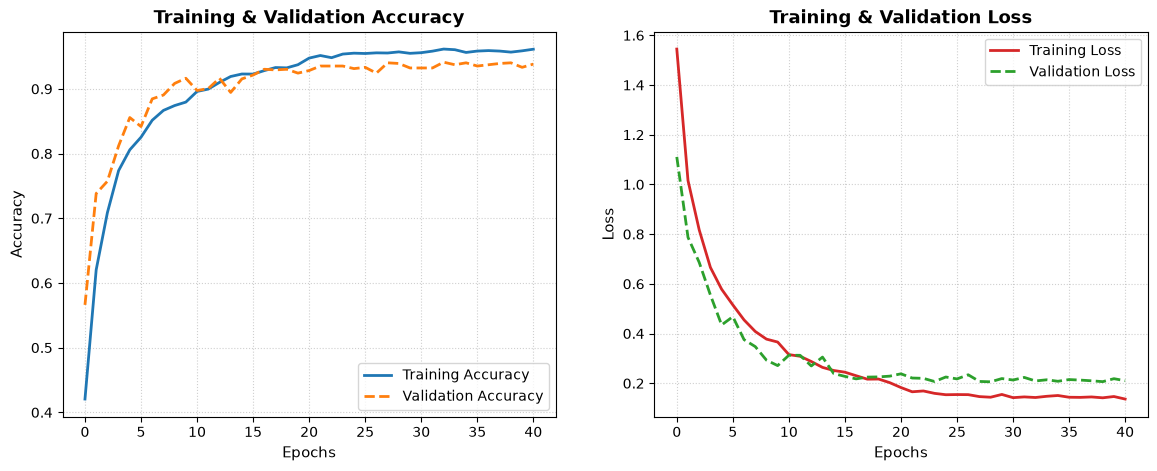

In [16]:
# ==========================================
# 6. HÀM VẼ BIỂU ĐỒ GIÁM SÁT (SENIOR STYLE)
# ==========================================
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Đồ thị Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2, linestyle='--')
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)

    # Đồ thị Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#2ca02c', linewidth=2, linestyle='--')
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Loss', fontsize=11)
    plt.title('Training & Validation Loss', fontsize=13, fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# Gọi hàm hiển thị biểu đồ
plot_training_history(history)

Calculating predictions...


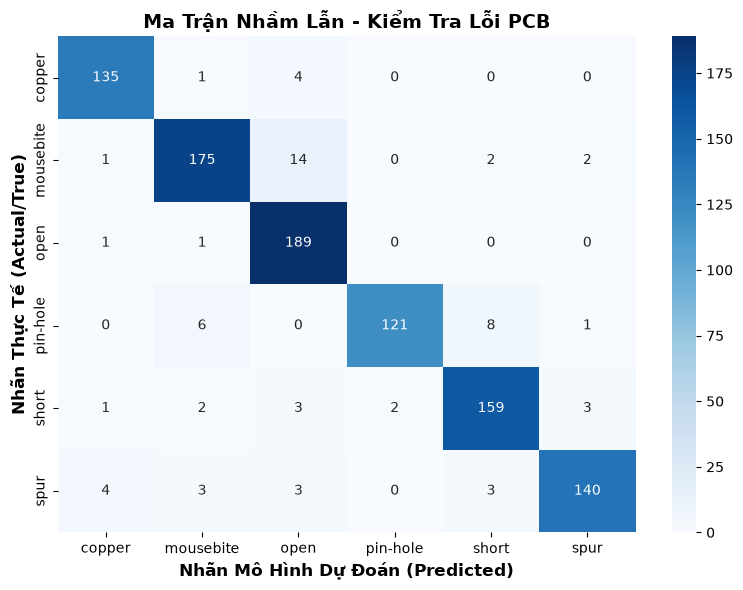

In [17]:
# 1. Dự đoán nhãn trên tập Test độc lập
import seaborn as sns
print("Calculating predictions...")
y_true = []
y_pred = []

# Duyệt qua tập test để lấy nhãn thật và nhãn dự đoán
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=-1))

# 2. Tạo ma trận nhầm lẫn
cm = tf.math.confusion_matrix(
    labels=y_true,
    predictions=y_pred,
    num_classes=NUM_CLASSES
).numpy()

# 3. Vẽ biểu đồ nhiệt trực quan (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Nhãn Mô Hình Dự Đoán (Predicted)', fontsize=12, fontweight='bold')
plt.ylabel('Nhãn Thực Tế (Actual/True)', fontsize=12, fontweight='bold')
plt.title('Ma Trận Nhầm Lẫn - Kiểm Tra Lỗi PCB', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# 1. Lấy độ chính xác của tập Train ở Epoch cuối cùng (hoặc tốt nhất)
# Ở log của bạn: accuracy: 0.9584
train_acc = history.history['accuracy'][-1] 

# 2. Đánh giá mô hình trên tập Test để lấy Test Accuracy
# Ở log của bạn: Test Accuracy: 36.59% (0.3659)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

# 3. Tính toán khoảng cách chênh lệch (Gap)
gap = (train_acc - test_acc) * 100

print("="*50)
print(f"{'TẬP DỮ LIỆU':<20} | {'ĐỘ CHÍNH XÁC (ACCURACY)':<25}")
print("="*50)
print(f"{'Training Set':<20} | {train_acc*100:.2f}%")
print(f"{'Testing Set':<20} | {test_acc*100:.2f}%")
print("-"*50)
print(f"Khoảng chênh lệch (Gap): {gap:.2f}%")
print("="*50)

# Tự động chẩn đoán lỗi hệ thống
if gap > 10.0:
    print("🚨 CHẨN ĐOÁN: Mô hình bị OVERFITTING nghiêm trọng (Học vẹt).")
    print("👉 Giải pháp: Cần tăng thêm Dropout, giảm bớt số Node lớp Dense hoặc thêm Data Augmentation.")
elif train_acc < 0.70 and test_acc < 0.70:
    print("⚠️ CHẨN ĐOÁN: Mô hình bị UNDERFITTING (Chưa học đủ tính năng).")
    print("👉 Giải pháp: Tăng số lượng bộ lọc Conv2D hoặc train thêm nhiều Epoch hơn.")
else:
    print("✅ CHẨN ĐOÁN: Mô hình đạt trạng thái tốt (Good Fit), độ chênh lệch an toàn.")
print("="*50)

TẬP DỮ LIỆU          | ĐỘ CHÍNH XÁC (ACCURACY)  
Training Set         | 93.57%
Testing Set          | 94.11%
--------------------------------------------------
Khoảng chênh lệch (Gap): -0.53%
✅ CHẨN ĐOÁN: Mô hình đạt trạng thái tốt (Good Fit), độ chênh lệch an toàn.


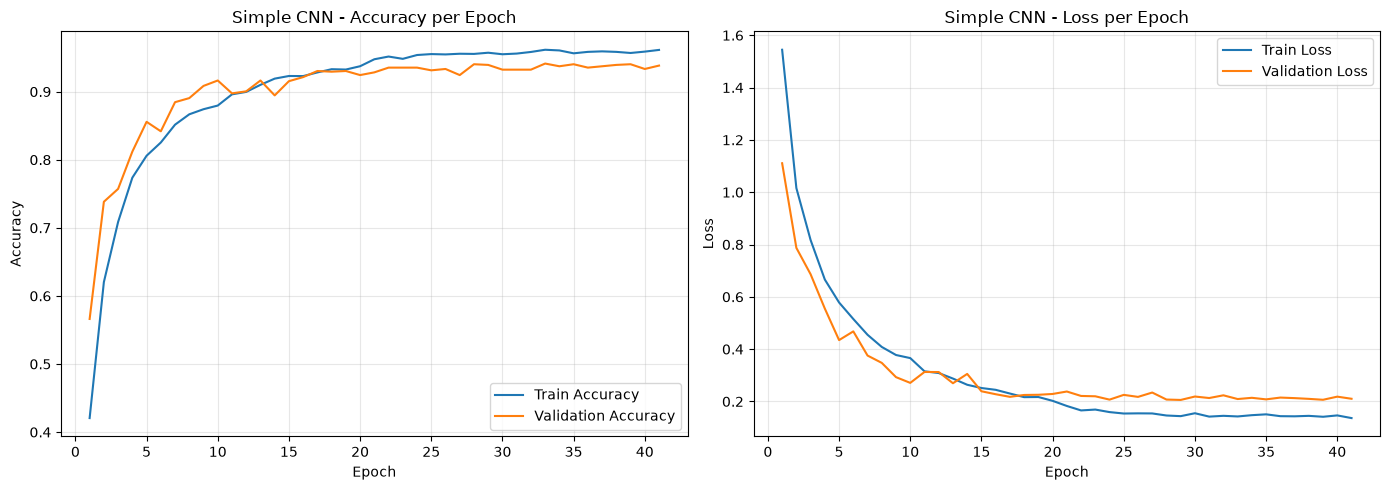

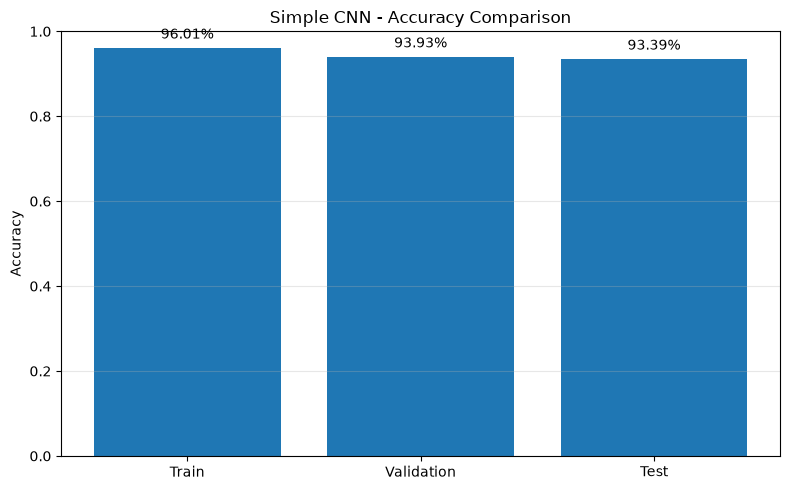

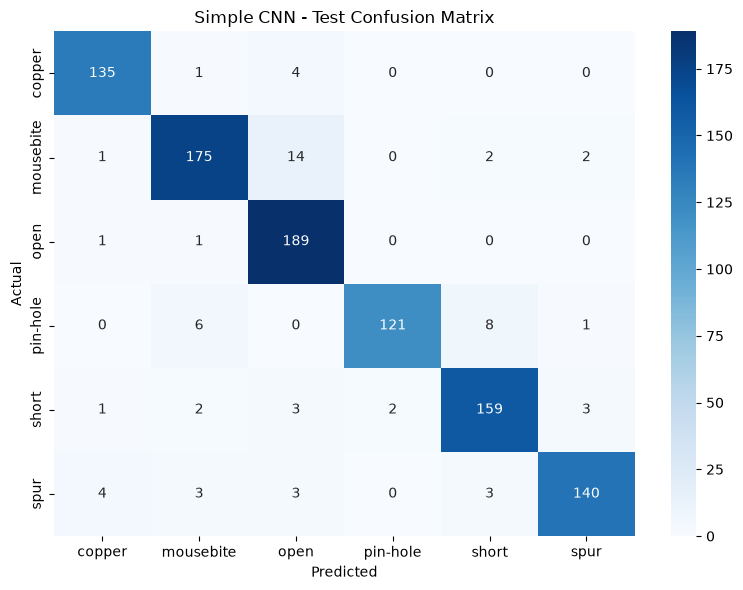

\n===== KẾT QUẢ ĐÃ ĐƯỢC LƯU =====
Thư mục: D:\PCB Defect Detection\outputs\simplecnn_output\run_20261010_163542
Train Accuracy:      96.01%
Validation Accuracy: 93.93%
Test Accuracy:       93.39%
Các file: metrics.json, metrics.csv, training_history.csv, training_curves.png, accuracy_comparison.png, confusion_matrix.png


In [18]:
# ==========================================
# 7. XUẤT KẾT QUẢ MỖI LẦN CHẠY
# ==========================================
from pathlib import Path
from datetime import datetime
import csv
import json
import matplotlib.pyplot as plt
import numpy as np

# Tạo thư mục output/simplecnn_output/<run_timestamp>/ để không ghi đè kết quả cũ
OUTPUT_ROOT = Path("outputs") / "simplecnn_output"
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = OUTPUT_ROOT / f"run_{RUN_ID}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

# Đánh giá accuracy trên cả 3 tập bằng model cuối cùng sau EarlyStopping
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

# Lưu các chỉ số tổng hợp
metrics = {
    "run_id": RUN_ID,
    "train_accuracy": float(train_acc),
    "validation_accuracy": float(val_acc),
    "test_accuracy": float(test_acc),
    "train_loss": float(train_loss),
    "validation_loss": float(val_loss),
    "test_loss": float(test_loss),
    "epochs_completed": len(history.history.get("accuracy", [])),
    "best_validation_accuracy": float(max(history.history["val_accuracy"])),
    "best_validation_loss": float(min(history.history["val_loss"])),
    "num_classes": int(NUM_CLASSES),
    "image_size": list(IMG_SIZE),
}
with open(RUN_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=4)

with open(RUN_DIR / "metrics.csv", "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)
    writer.writerow(["metric", "value"])
    for key, value in metrics.items():
        writer.writerow([key, value])

# Lưu lịch sử theo từng epoch
history_keys = list(history.history.keys())
with open(RUN_DIR / "training_history.csv", "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch"] + history_keys)
    epochs_count = len(history.history["accuracy"])
    for i in range(epochs_count):
        writer.writerow([i + 1] + [history.history[k][i] for k in history_keys])

# Biểu đồ Accuracy và Loss qua các epoch
epochs_range = range(1, len(history.history["accuracy"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, history.history["accuracy"], label="Train Accuracy")
axes[0].plot(epochs_range, history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Simple CNN - Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_range, history.history["loss"], label="Train Loss")
axes[1].plot(epochs_range, history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Simple CNN - Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
fig.tight_layout()
fig.savefig(RUN_DIR / "training_curves.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# Biểu đồ so sánh accuracy Train / Validation / Test
split_names = ["Train", "Validation", "Test"]
accuracies = [train_acc, val_acc, test_acc]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(split_names, accuracies)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("Simple CNN - Accuracy Comparison")
ax.grid(axis="y", alpha=0.3)
for bar, value in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.015,
            f"{value:.2%}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(RUN_DIR / "accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# Lưu confusion matrix nếu đã được tạo ở cell phía trên
if "cm" in globals():
    try:
        import seaborn as sns
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title("Simple CNN - Test Confusion Matrix")
        fig.tight_layout()
        fig.savefig(RUN_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Không lưu được confusion matrix: {e}")

print("\\n===== KẾT QUẢ ĐÃ ĐƯỢC LƯU =====")
print(f"Thư mục: {RUN_DIR.resolve()}")
print(f"Train Accuracy:      {train_acc:.2%}")
print(f"Validation Accuracy: {val_acc:.2%}")
print(f"Test Accuracy:       {test_acc:.2%}")
print("Các file: metrics.json, metrics.csv, training_history.csv, "
      "training_curves.png, accuracy_comparison.png"
      + (", confusion_matrix.png" if (RUN_DIR / "confusion_matrix.png").exists() else ""))
